# Produce $v_\beta$ vs. $v_\lambda$ diagram for NEOs observed towards anti-sun direction

In [1]:
## automatically reload any modules read below that might have changed (e.g. plots)
%reload_ext autoreload
%autoreload 2

In [3]:
# importing plotting and locus tools: 
import sys
sys.path.append('../src')
sys.path.append('src')
import NEOtools as nt
import NEOMOD3 as nm3  

In [4]:
import numpy as np
from numpy import sin, cos
from urllib.request import urlopen
from io import StringIO
import matplotlib.pyplot as plt
import pyarrow as pa
from scipy.interpolate import RegularGridInterpolator

In [5]:
import astropy.units as u
from astropy.time import Time
from astropy.coordinates import EarthLocation, get_body_barycentric_posvel, solar_system_ephemeris 

In [6]:
import adam_core.coordinates
from adam_core.time import Timestamp
from adam_core.coordinates import CartesianCoordinates, Origin
from adam_core.constants import KM_P_AU, S_P_DAY
from adam_core.orbits import Orbits
from adam_core.utils import get_perturber_state
from adam_core.coordinates.origin import OriginCodes

In [31]:
def compute_neomod3_weight(array4D, H_center, a_center, e_center, i_center,
                           d_au, ddot_kms, 
                           ra_deg=10.0, dec_deg=20.0, 
                           dra_deg_per_day=0.12, ddec_deg_per_day=0.22,
                           H0=19.0, i0=25.9, obstime_str="2025-09-16T00:00:00", what="w"):

    verbose = False
    
    time0 = !date +%s  

    obstime = Time(obstime_str)
    ra_rate_is_plain_dalpha = False
    
    
    # df, array4D, H_center, a_center, e_center, i_center = nm3.getNEOMOD3orbits()
    

    rubin_location = EarthLocation.from_geodetic( 
        lon=-70.7366*u.deg,   # longitude (west is negative)
        lat=-30.2407*u.deg,   # latitude
        height=2647*u.m       # elevation
        
    )
    # earth's barycentric vector rel to sun
    with solar_system_ephemeris.set('de432s'): 
        rE_bary, vE_bary = get_body_barycentric_posvel('earth', obstime)

    # convert to km and km/s arrays
    rE = np.array([rE_bary.x.to(u.km).value, #rE goes from sun to earth center
                   rE_bary.y.to(u.km).value,
                   rE_bary.z.to(u.km).value])
    
    vE = np.array([vE_bary.x.to(u.km/u.s).value, #vE goes from sun to earth center
                   vE_bary.y.to(u.km/u.s).value,
                   vE_bary.z.to(u.km/u.s).value])
    
    obs_geo = rubin_location.get_gcrs(obstime)
    r_obs = np.array([obs_geo.cartesian.x.to(u.km).value,
                      obs_geo.cartesian.y.to(u.km).value,
                      obs_geo.cartesian.z.to(u.km).value])
 

    r_geo, v_geo = observables_to_geocentric_state(ra_deg, dec_deg, dra_deg_per_day, ddec_deg_per_day, d_au, ddot_kms)

    r_helio, v_helio = geo_to_topo(r_geo, v_geo, rE, vE, r_obs, obstime) #so not running the random numbers anymore

    #print("Heliocentric position [km]:", r_helio)
    #print("Heliocentric velocity [km/s]:", v_helio)



    mu_sun = 1.32712440018e11  # [km^3/s^2] gm of the sun
    r_vec = np.array(r_helio, dtype=float)
    v_vec = np.array(v_helio, dtype=float)
    #print(r_vec)
    #print(v_vec)

    
    r = np.array(r_vec, dtype=float)
    v = np.array(v_vec, dtype=float)
    R = np.linalg.norm(r)
    V = np.linalg.norm(v)

    #r_helio = np.array([ 1.49731310e+08, -1.54951809e+07, -4.56222082e+06 ])  # km
    #r_vec here does the same thing but doesnt use random values so 
    #v_helio = np.array([ 4.15172845, 25.02778897, 12.21628245 ]) # km/s
    #same with v_vec 
    
    obstime = Time(["2025-09-16T00:00:00"], scale="tdb")  # Note converted this to a list 
    if r_vec.ndim == 1:
        r_vec = r_vec[np.newaxis, :]
        v_vec = v_vec[np.newaxis, :]
        #print("r_vec:", r_vec)



    
    cartesian_coordinates = CartesianCoordinates.from_kwargs(
        x=r_vec[:, 0] / KM_P_AU,
        y=r_vec[:, 1] / KM_P_AU,
        z=r_vec[:, 2] / KM_P_AU,
        vx=v_vec[:, 0] / KM_P_AU * S_P_DAY,
        vy=v_vec[:, 1] / KM_P_AU * S_P_DAY,
        vz=v_vec[:, 2] / KM_P_AU * S_P_DAY,
        time=Timestamp.from_astropy(obstime),
        origin=Origin.from_kwargs(code=pa.repeat("SUN", len(r_vec))),
        frame="equatorial" # ecliptic is the other choice
    )
    
    keplerian_coordinates = cartesian_coordinates.to_keplerian()
    
    if verbose:      
        time1 = !date +%s  
        runTime = int(time1[0])-int(time0[0])
        print('      Step 1 in cnw', runTime, 'seconds.') 
    
    # Might be useful to store them into an orbits object:
    orbits = Orbits.from_kwargs(
        orbit_id=[f"orbit_{i:08d}" for i in range(len(cartesian_coordinates))],
        coordinates=cartesian_coordinates,
    )
    # The Orbits class expects cartesian coordinates but its trivial to convert
    # so that log(0) doesn't happen
    _eps = 1e-300
    log_grid = np.log(array4D + _eps)
    if False:
        interp4D = array4D
    else:
        interp4D = RegularGridInterpolator(
            (H_center, a_center, e_center, i_center),
            log_grid,
            bounds_error=False,
            fill_value=-np.inf
        )
    

    if verbose:      
        time2 = !date +%s  
        runTime = int(time2[0])-int(time1[0])
        print('        Step 2 in cnw', runTime, 'seconds.') 
    

    # fixed vals
    #H0 = 19.0         # abs magnitude
    #i0 = 10.0         # deg

    # redundant (and thus volatile) with getNEOMOD3bins in NEOMOD3.py 
    n_H, H_min, H_max = 52, 15.0, 28.0
    n_a, a_min, a_max = 42, 0.0, 4.2
    n_e, e_min, e_max = 25, 0.0, 1.0
    n_i, i_min, i_max = 22, 0.0, 88.0

    Na, Ne = 200, 200
    a_grid = np.linspace(a_min, a_max, Na)
    e_grid = np.linspace(e_min, e_max, Ne)
    A, E = np.meshgrid(a_grid, e_grid, indexing="xy")

    #W = neomod3_slice_ae(H0, i0, A, E, interp4D)    

    

    #a_val, e_val = 0.915, 0.109
    a_val = keplerian_coordinates.a[0].as_py()
    e_val = keplerian_coordinates.e[0].as_py()
    i_val = keplerian_coordinates.i[0].as_py()
    #print(keplerian_coordinates.a)
    #print("a_val:",a_val)
    #print("e_val:",e_val)

    #print("PRE about to call neomod3_at_orbit")
    
    score = score_from_elements(a_val, e_val, 19.0, i_val, interp4D)
    
    if verbose:      
        time3 = !date +%s  
        runTime = int(time3[0])-int(time2[0])
        print('      Step 3 in cnw', runTime, 'seconds.') 

    return score, a_val, e_val, i_val

In [7]:
# converts vectors to geocentric state vectors 
def observables_to_geocentric_state(ra_deg, dec_deg, dra_deg_per_day, ddec_deg_per_day,
                                    d_au, ddot_kms, ra_rate_is_plain_dalpha=False):
        # converting from degrees to radians
        ra  = np.deg2rad(ra_deg) 
        dec = np.deg2rad(dec_deg)
        l_hat, e_ra, e_dec = sky_basis(ra, dec)
         # angular rate conversion from deg/day to rad/s
        dra  = np.deg2rad(dra_deg_per_day)  / 86400.0
        ddec = np.deg2rad(ddec_deg_per_day) / 86400.0
        # if the RA rate is plain d alpha/dt, convert to u alpha⋅cos delta sky-plane rate
        if ra_rate_is_plain_dalpha:
             dra *= np.cos(dec)

        d_km = d_au * AU_km
        # multiplying l_hat by the rand dist. value gives actual geocentric pos vector of obj
        r_geo = d_km * l_hat  # vector from earth center to obj

        # speed
        v_rad = ddot_kms * l_hat
        v_tan = d_km * (dra * e_ra + ddec * e_dec)
        v_geo = v_rad + v_tan
        
        return r_geo, v_geo
    
AU_km = 149_597_870.7

# creates a right-handed vector basis that points to object from observer
def sky_basis(ra_rad, dec_rad):
        l_hat = np.array([cos(dec_rad)*cos(ra_rad), # vector that points to object's pos on sky from observer
                          cos(dec_rad)*sin(ra_rad),
                          sin(dec_rad)])
        e_ra  = np.array([-sin(ra_rad),  cos(ra_rad), 0.0]) # vector towards increasing RA - points east, 90 deg to l_hat
        e_dec = np.array([-sin(dec_rad)*cos(ra_rad), # vector towards increasing dec - points north
                          -sin(dec_rad)*sin(ra_rad),
                          cos(dec_rad)])
        return l_hat, e_ra, e_dec # turning angular rates into linear velocities

#converts geocentric vectors to topocentric vectors 
def geo_to_topo(r_geo_km, v_geo_kms, rE, vE, r_obs, obstime):
        # convert r_geo, v_geo for obj to heliocentric r_topo, v_topo for an observer at rubin
        # from center of earth to an observer now at rubin
        obstime = Time(obstime)
        # earth's barycentric (heliocentric) state was done in previous step
        # so was observer's offset from center of earth
        # adding the offsets
        r_topo = rE + r_obs + r_geo_km
        v_topo = vE + v_geo_kms
        return r_topo, v_topo # asteroid position, vec going from sun to asteroid assuming youre at rubin

    

def score_from_elements(a_AU, e, H0, i0, interp4D):
    # checks if orbit is bound right
    if (a_AU <= 0) or (e >= 1.0) or (e < 0):
        
        return 0.0

    # clip gently to model box
    a_cl = np.clip(a_AU, 0.0, 4.2 - 1e-9)
    e_cl = np.clip(e,      0.0, 1.0 - 1e-9)
    i_cl = np.clip(i0,  0.0, 88.0 - 1e-9)

    log_w = float(interp4D([[H0, a_cl, e_cl, i_cl]])[0])
    return 0.0 if not np.isfinite(log_w) else float(np.exp(log_w))


## TESTING compute_neomod3_weight

In [9]:
test_neomod = compute_neomod3_weight(array4D, H_center, a_center, e_center, i_center,
    d_au = 0.20,
    ddot_kms = 3.0,
    
)

print("NEOMOD3 weight score, a, e , i:", test_neomod)

NEOMOD3 weight score, a, e , i: (0.39767976093729207, 1.8347951398844098, 0.370408545698434, 26.107074758880806)


## real test: calling weight_marginalized_over_d_and_ddot

In [37]:
def weight_marginalized_over_d_and_ddot(array4D, H_center, a_center, e_center, i_center,
                                        ra_deg, dec_deg, dra_deg_day, ddec_deg_day,
                                        H0=19.0, i0=25.9, obstime_str="2025-09-23T00:00:00"):
    w_sum = 0.0
    d_grid, ddot_grid = makeddotgrids()
    # loop 
    for d in d_grid:
        for vlos in ddot_grid:
            out = compute_neomod3_weight(array4D, H_center, a_center, e_center, i_center,
                            d_au=d, ddot_kms=vlos,
                            ra_deg=ra_deg, dec_deg=dec_deg,
                            dra_deg_per_day=dra_deg_day, ddec_deg_per_day=ddec_deg_day,
                            H0=H0, i0=i0, obstime_str=obstime_str, what="w")
            w = out[0] if isinstance(out, tuple) else float(out)
            w_sum += w
    return w_sum


def makeddotgrids():
    d_min, d_max, Nd = 0.05, 5.0, 10          # AU  
    v_min, v_max, Nv = -60.0, 60.0, 10         # km/s

    d_grid   = np.linspace(d_min, d_max, Nd)
    ddot_grid= np.linspace(v_min, v_max, Nv)
    return d_grid, ddot_grid

In [8]:
df, array4D, H_center, a_center, e_center, i_center = nm3.getNEOMOD3orbits()

In [14]:
import NEOtools as nt

# anti-Sun at Sep 23 = equinox so RA = 0, Dec = 0
ra0_deg, dec0_deg = 0.0, 0.0
obstime_str = "2025-09-23T00:00:00"

 
# N_rate = 31
# N_rate = 3    # 100 seconds (verbose in weights)
# N_rate = 3   #  27 seconds  (no verbose), or 3 sec/iteration
#N_rate = 11   # 383 (6.5 min) 
#N_rate = 31   # 3093 sec (50 min)
#N_rate = 51   # 8552 sec (142 min)
# N_rate = 101    # sec ( min)
N_rate = 2


dra_vals  = np.linspace(-0.6, 0.6, N_rate)
ddec_vals = np.linspace(-0.6, 0.6, N_rate)


vlam_edges = np.linspace(-0.6, 0.6, 121)
vbet_edges = np.linspace(-0.6, 0.6, 121)


H = np.zeros((len(vbet_edges)-1, len(vlam_edges)-1), dtype=float)

verbose = False 

## assign colors to MSRG subsample
timeStart = !date +%s  

d_grid, ddot_grid = nt.Zmakeddotgrids()

for dra in dra_vals:
    print('dra = ', dra)
    for ddec in ddec_vals:
        if verbose: print('      ddec = ', ddec)
        if verbose: timeNow0 = !date +%s  
        vlam, vbet = nt.radec_rates_to_ecliptic_rates(ra0_deg, dec0_deg, dra, ddec)
        if verbose: 
            timeNow1 = !date +%s  
            timeLapsed = int(timeNow1[0])-int(timeNow0[0])
            print('  First in', timeLapsed, 'seconds.') 
        w_int = nt.weight_marg_over_d_and_ddot(array4D, H_center, a_center, e_center, i_center,
                                                    d_grid, ddot_grid, ra0_deg, dec0_deg, dra, ddec,
                                                    H0=19.0, i0=25.9, obstime_str=obstime_str)
         
        if verbose: 
            timeNow2 = !date +%s  
            timeLapsed = int(timeNow2[0])-int(timeNow1[0])
            print('  Second in', timeLapsed, 'seconds.') 
        
        i = np.searchsorted(vlam_edges, vlam) - 1
        j = np.searchsorted(vbet_edges, vbet) - 1
        if 0 <= i < H.shape[1] and 0 <= j < H.shape[0]:
            H[j, i] += w_int
        if verbose:             
            timeNow3 = !date +%s  
            timeLapsed = int(timeNow3[0])-int(timeNow2[0])
            print('  Third in', timeLapsed, 'seconds.') 
       
print('last w_int:', w_int)

timeEnd = !date +%s  
runTime = int(timeEnd[0])-int(timeStart[0])
print('Finished in', runTime, 'seconds.') 
# abour 3 second per iteration

dra =  -0.6
score: 0.0
score: 0.0
score: 0.0


TypeError: 'numpy.ndarray' object is not callable

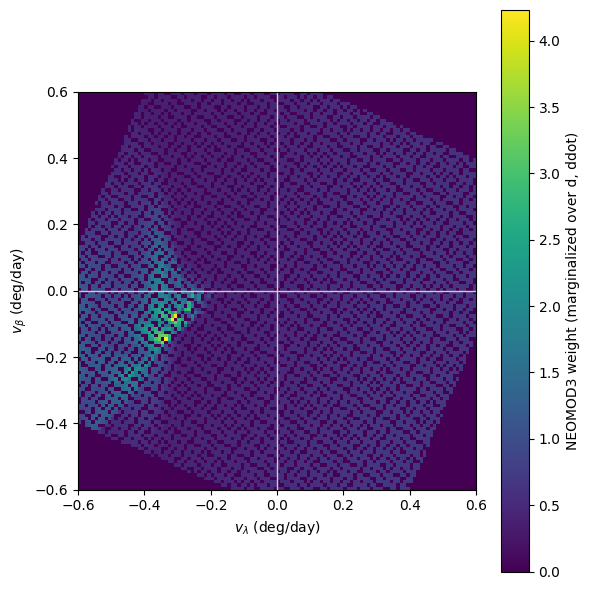

In [36]:
# CELL ABOVE TAKES 9 MINS TO RUN DO NOT RUN AGAIN ON ACCIDENT OR ITS AN UNSKIPPABLE CUTSCENE!!!
from matplotlib import cm
plt.figure(figsize=(6.0, 6.0))
extent = [vlam_edges[0], vlam_edges[-1], vbet_edges[0], vbet_edges[-1]]
 
my_viridis = cm.get_cmap("viridis", 1024).with_extremes(under="white")
im = plt.imshow(H, origin="lower", extent=extent, cmap=my_viridis, aspect="equal")


plt.colorbar(label="NEOMOD3 weight (marginalized over d, ddot)")

plt.axhline(0, color="0.8", lw=1)
plt.axvline(0, color="0.8", lw=1)
plt.xlabel(r"$v_\lambda$ (deg/day)")
plt.ylabel(r"$v_\beta$ (deg/day)")
#plt.title("v_lambda–v_beta distribution (integrated over d [0.05,5] AU, ddot [−60,60] km/s)\n"
#          f"{obstime_str}")
plt.tight_layout()
plt.show()

In [77]:
import NEOtools as nt

In [79]:
obstime, rE, vE, r_obs = nt.get_Earth_and_observer("2025-09-23T00:00:00")

In [80]:
obstime, rE, vE, r_obs 

(<Time object: scale='utc' format='isot' value=2025-09-23T00:00:00.000>,
 array([ 1.49562144e+08, -1.05931279e+06, -4.36222633e+05]),
 array([-0.40867228, 27.23758648, 11.80785384]),
 array([ 1971.88181998, -5149.79204259, -3199.52643587]))